# Final Python Notebook 1: Data Understanding and Preprocessing
**Author:** Branavan Kuganesan  
**Module:** 5DATA002W.2 Machine Learning & Data Mining  
**Dataset:** Loan Approval Dataset  
**Code Peer Reviewer:** [Peer Reviewer Name]  
**Date of Review:** [Date]


## 1. Import Libraries
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib and seaborn for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Import LabelEncoder for encoding categorical variables
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set display options for readability
pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")


Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


## 2. Load and Inspect the Dataset
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [2]:
# Load the loan approval dataset from CSV file
df = pd.read_csv('loan_approval_data.csv')

# Display the first five rows to understand the structure
df.head()


,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


### 2.1 Dataset Dimensions
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [3]:
# Print the shape of the dataset (rows, columns)
print("Dataset shape:", df.shape)

# Display all column names and their data types
print("\nColumn names and data types:")
print(df.dtypes)


Dataset shape: (58645, 13)

Column names and data types:
id                           int64
age                        float64
income                       int64
home_ownership              object
emplyment_length             int64
loan_intent                 object
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file     object
credit_history_length        int64
loan_approval_status         int64
max_allowed_loan             int64
dtype: object


## 3. Exploratory Data Analysis (EDA)
*Code block reused from: Code Reuse Session 1 — Data Understanding*

### 3.1 Descriptive Statistics
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [4]:
# Generate descriptive statistics for all numerical columns
df.describe()


,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


### 3.2 Class Distribution — Loan Approval Status
*Code block reused from: Code Reuse Session 1 — Data Understanding*

Loan Approval Status distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

Percentage distribution:
loan_approval_status
0    85.76
1    14.24
Name: count, dtype: float64


/var/folders/0h/m0m4qfr55tq6_s337r9x7p680000gn/T/ipykernel_41277/4058507046.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_approval_status', data=df, palette='Set2')


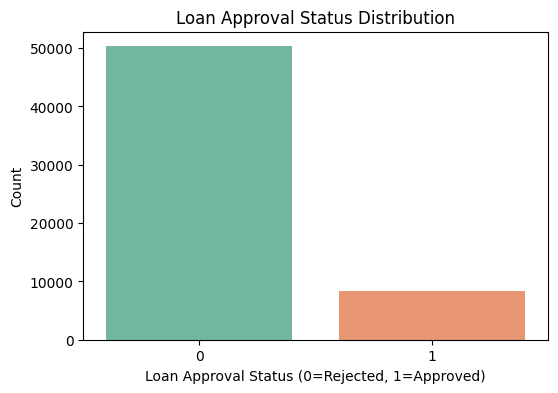

In [5]:
# Count the number of approved (1) vs rejected (0) loan applications
approval_counts = df['loan_approval_status'].value_counts()
print("Loan Approval Status distribution:")
print(approval_counts)

# Calculate percentage distribution
print("\nPercentage distribution:")
print((approval_counts / len(df) * 100).round(2))

# Plot a bar chart of class distribution
plt.figure(figsize=(6, 4))
# Create bar plot with labelled axes
sns.countplot(x='loan_approval_status', data=df, palette='Set2')
plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Approval Status (0=Rejected, 1=Approved)')
plt.ylabel('Count')
plt.show()


### 3.3 Categorical Feature Distributions
*Code block reused from: Code Reuse Session 1 — Data Understanding*

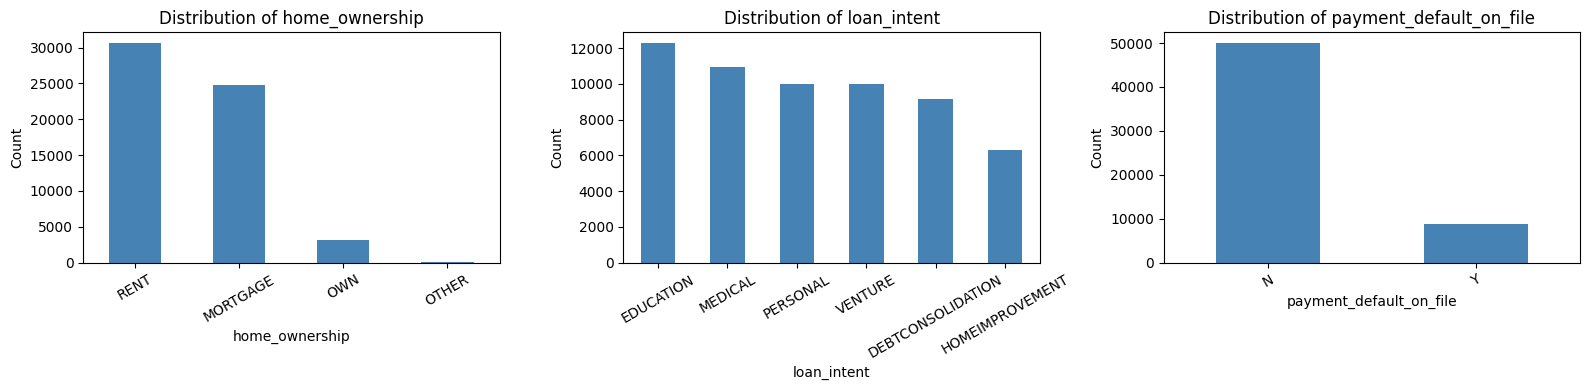

In [6]:
# List of categorical columns to visualise
categorical_cols = ['home_ownership', 'loan_intent', 'payment_default_on_file']

# Loop through each categorical column and plot value counts
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(categorical_cols):
    # Plot count of each category
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 3.4 Numerical Feature Distributions
*Code block reused from: Code Reuse Session 1 — Data Understanding*

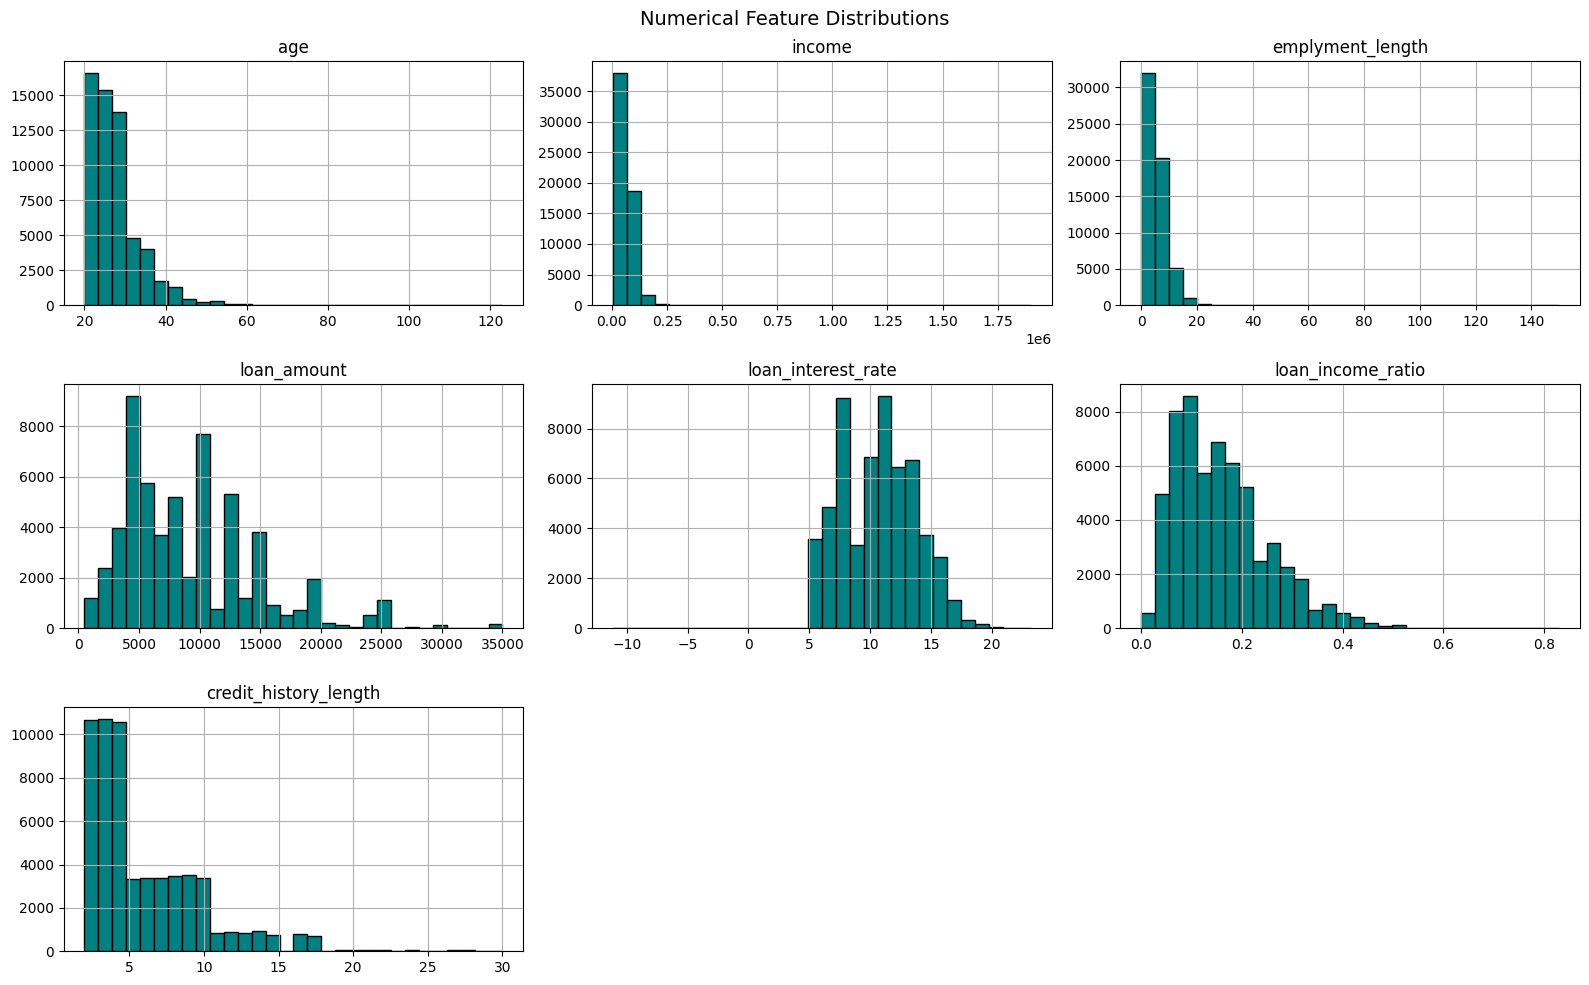

In [7]:
# Select numerical columns excluding id and target
numerical_cols = ['age', 'income', 'emplyment_length', 'loan_amount',
                  'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']

# Plot histogram for each numerical feature
df[numerical_cols].hist(bins=30, figsize=(16, 10), color='teal', edgecolor='black')
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()


### 3.5 Correlation Heatmap
*Code block reused from: Code Reuse Session 1 — Data Understanding*

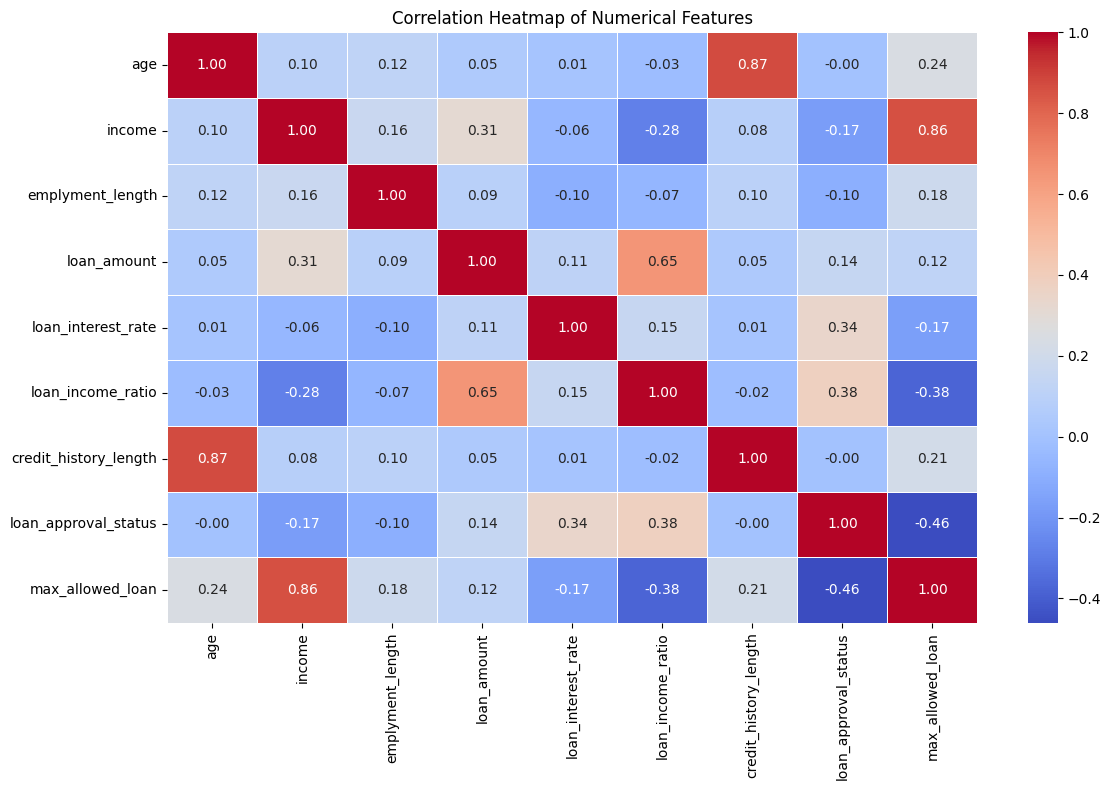

In [8]:
# Compute correlation matrix for numerical features
corr_matrix = df[numerical_cols + ['loan_approval_status', 'max_allowed_loan']].corr()

# Plot heatmap to visualise feature correlations
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


## 4. Handling Missing Values
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [9]:
# Display count of missing values per column
print("Missing values per column:")
print(df.isnull().sum())
print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing values per column:
id                          0
age                         6
income                      0
home_ownership              0
emplyment_length            0
loan_intent                 0
loan_amount                 0
loan_interest_rate         11
loan_income_ratio           0
payment_default_on_file     5
credit_history_length       0
loan_approval_status        0
max_allowed_loan            0
dtype: int64

Percentage missing:
id                         0.00
age                        0.01
income                     0.00
home_ownership             0.00
emplyment_length           0.00
loan_intent                0.00
loan_amount                0.00
loan_interest_rate         0.02
loan_income_ratio          0.00
payment_default_on_file    0.01
credit_history_length      0.00
loan_approval_status       0.00
max_allowed_loan           0.00
dtype: float64


### 4.1 Impute Missing Values
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [10]:
# Impute missing 'age' values with the median (robust to skew and outliers)
df['age'].fillna(df['age'].median(), inplace=True)

# Impute missing 'loan_interest_rate' with the median
df['loan_interest_rate'].fillna(df['loan_interest_rate'].median(), inplace=True)

# Impute missing 'payment_default_on_file' with the mode (most frequent category)
df['payment_default_on_file'].fillna(df['payment_default_on_file'].mode()[0], inplace=True)

# Confirm no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
id                         0
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64


/var/folders/0h/m0m4qfr55tq6_s337r9x7p680000gn/T/ipykernel_41277/1633198082.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/var/folders/0h/m0m4qfr55tq6_s337r9x7p680000gn/T/ipykernel_41277/1633198082.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

## 5. Outlier Detection and Handling
*Code block reused from: Code Reuse Session 1 — Data Understanding*

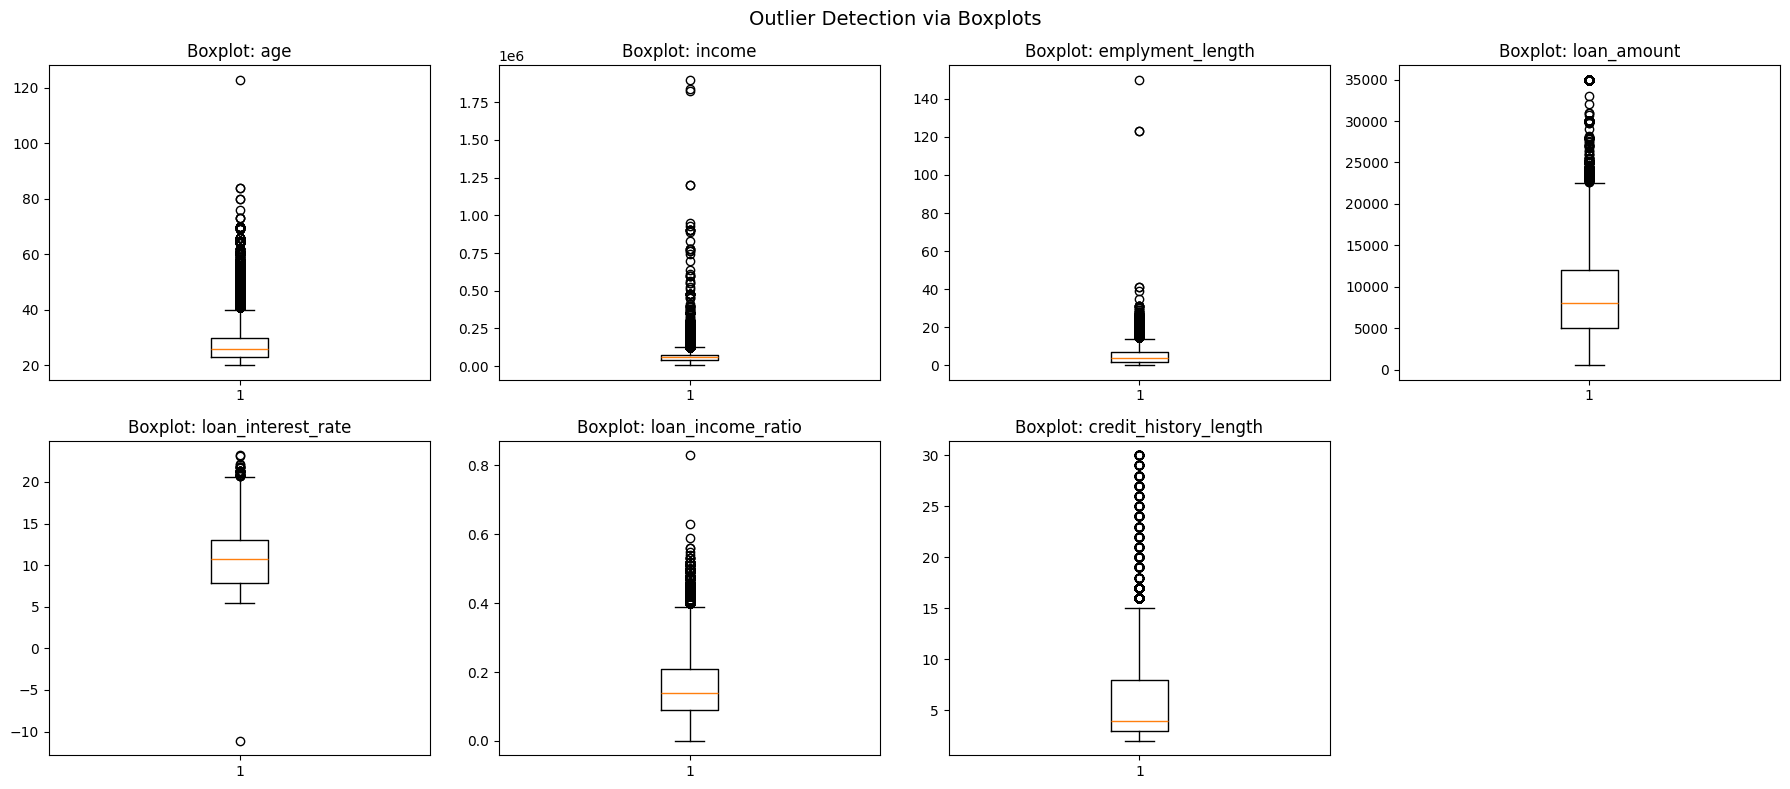

In [11]:
# Plot boxplots to visually identify outliers in numerical columns
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    # Boxplot for each numerical feature
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}')
axes[-1].set_visible(False)
plt.suptitle('Outlier Detection via Boxplots', fontsize=14)
plt.tight_layout()
plt.show()


In [12]:
# Remove extreme outlier in 'age' — max age of 123 is biologically implausible
print("Age range before:", df['age'].min(), "-", df['age'].max())

# Cap age at 100 as a reasonable upper bound
df = df[df['age'] <= 100]
print("Age range after:", df['age'].min(), "-", df['age'].max())

# Remove negative values in 'max_allowed_loan' — logically invalid
print("\nNegative max_allowed_loan count:", (df['max_allowed_loan'] < 0).sum())
df = df[df['max_allowed_loan'] >= 0]
print("Rows remaining after outlier removal:", df.shape[0])


Age range before: 20.0 - 123.0
Age range after: 20.0 - 84.0

Negative max_allowed_loan count: 3
Rows remaining after outlier removal: 58641


## 6. Encoding Categorical Variables
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [13]:
# Initialise LabelEncoder
le = LabelEncoder()

# Encode 'home_ownership' categorical column into numeric labels
df['home_ownership'] = le.fit_transform(df['home_ownership'])
print("home_ownership classes:", list(le.classes_))

# Encode 'loan_intent' categorical column into numeric labels
df['loan_intent'] = le.fit_transform(df['loan_intent'])
print("loan_intent classes:", list(le.classes_))

# Encode 'payment_default_on_file' binary column (Y/N) into numeric labels
df['payment_default_on_file'] = le.fit_transform(df['payment_default_on_file'])
print("payment_default_on_file classes:", list(le.classes_))

# Confirm all columns are now numeric
print("\nData types after encoding:")
print(df.dtypes)


home_ownership classes: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
loan_intent classes: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
payment_default_on_file classes: ['N', 'Y']

Data types after encoding:
id                           int64
age                        float64
income                       int64
home_ownership               int64
emplyment_length             int64
loan_intent                  int64
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file      int64
credit_history_length        int64
loan_approval_status         int64
max_allowed_loan             int64
dtype: object


## 7. Feature Scaling
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [14]:
# Define features used for modelling (excluding id and targets)
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
                'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
                'payment_default_on_file', 'credit_history_length']

# Initialise StandardScaler to normalise feature values
scaler = StandardScaler()

# Fit and transform the feature columns
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Feature scaling complete.")
print("\nSample scaled values:")
print(df_scaled[feature_cols].head(3))


Feature scaling complete.

Sample scaled values:
        age    income  home_ownership  emplyment_length  loan_intent  \
3  2.068187  3.109795        0.913176         -0.425359    -0.881911   
4  2.068187  0.684172       -1.152168         -0.425359    -0.301496   
5  2.068187  1.765215       -1.152168          1.072764     1.439749   

   loan_amount  loan_interest_rate  loan_income_ratio  \
3     4.634881           -0.882000           0.335529   
4     4.634881            0.574018           2.516751   
5     3.736060           -0.914942           0.771774   

   payment_default_on_file  credit_history_length  
3                -0.417351               1.287159  
4                -0.417351               2.031714  
5                -0.417351               1.783529  


## 8. Prepare Subset for Case Study A — Classification
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [15]:
# Select features and target for classification (loan approval status)
X_clf = df_scaled[feature_cols]
y_clf = df_scaled['loan_approval_status']

# Display dimensions and feature list for Case Study A
print("Classification dataset shape:", X_clf.shape)
print("Feature names:", X_clf.columns.tolist())
print("Target distribution:")
print(y_clf.value_counts())


Classification dataset shape: (58641, 10)
Feature names: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Target distribution:
loan_approval_status
0    50291
1     8350
Name: count, dtype: int64


## 9. Prepare Subset for Case Study B — Regression
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [16]:
# Filter dataset to only approved clients (loan_approval_status == 1)
df_approved = df_scaled[df_scaled['loan_approval_status'] == 1].copy()

# Define features and target for regression (max_allowed_loan)
X_reg = df_approved[feature_cols]
y_reg = df_approved['max_allowed_loan']

# Display dimensions and feature list for Case Study B
print("Regression dataset shape (approved clients only):", X_reg.shape)
print("Feature names:", X_reg.columns.tolist())
print("Target (max_allowed_loan) statistics:")
print(y_reg.describe())


Regression dataset shape (approved clients only): (8350, 10)
Feature names: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Target (max_allowed_loan) statistics:
count    8350.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: max_allowed_loan, dtype: float64


## 10. Export Cleaned Dataset
*Code block reused from: Code Reuse Session 1 — Data Understanding*

In [17]:
# Save the cleaned and encoded full dataframe for use in Notebooks 2 and 3
df_scaled.to_csv('loan_approval_cleaned.csv', index=False)
print("Cleaned dataset saved as 'loan_approval_cleaned.csv'")
print("Final dataset shape:", df_scaled.shape)


Cleaned dataset saved as 'loan_approval_cleaned.csv'
Final dataset shape: (58641, 13)
